Some basic tasks to get used to using qiskit before starting some proper projects. This first section creates a statevector u and displays it in a LaTeX format. It is then measured to collapse the state into one of the two classical components at probabilities given by the modulus squared of the component of each state. This output collapsed state is displayed in the same format.

In [1]:
from qiskit import __version__
print(__version__)

import qiskit
from qiskit.quantum_info import Statevector
import numpy as np

u = Statevector([1 / np.sqrt(2), 1 / np.sqrt(2)])
display(u.is_valid())

display(u.draw("latex"))

outcome, state = u.measure()
print("Measured: {outcome}\nPost-measurement State:")
display(state.draw("latex"))


2.2.3


True

<IPython.core.display.Latex object>

Measured: {outcome}
Post-measurement State:


<IPython.core.display.Latex object>

We will now add operators to the system using the qiskit Operator function. This will allow us to apply unitary matrix operations to a generated statevector.

In [2]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1/np.sqrt(2), 1/np.sqrt(2)], [1/np.sqrt(2), -1/np.sqrt(2)]])
S = Operator([[1,0], [0,1.0j]])
T = Operator([[1,0], [0, (1 + 1.0j)/np.sqrt(2)]])

display(Y.draw("latex"))
display(H.draw("latex"))
display(S.draw("latex"))
display(T.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

We can then apply these Operators to the state vectors using the qiskit evolve method.

In [3]:
v = Statevector([1,0])

v_Y = v.evolve(Y)
v_H = v.evolve(H)
v_S = v.evolve(S)
v_T = v.evolve(T)

display(v_Y.draw("latex"))
display(v_H.draw("latex"))
display(v_S.draw("latex"))
display(v_T.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

We can now also take a brief look at quantum circuits and how they function with qiskit.

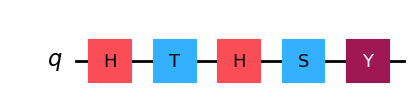

In [4]:
import pylatexenc
from qiskit import QuantumCircuit
from IPython.display import display

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output='mpl'))

We can now begin to look at multiple systems. We start my initializing a quantum state $| \psi \rangle$
 as the tensor product of two statevectors, $| 0 \rangle$ and $| 1 \rangle$, which we can perform with the statevector.tensor method. 

In [5]:
from qiskit.quantum_info import Statevector, Operator

zero = Statevector.from_label("0")
one = Statevector.from_label("1")

psi = zero.tensor(one) # Computes tensor product of Zero * One
display(psi.draw("Latex"))

<IPython.core.display.Latex object>

We can even try this with more complex statevectors, some of which are included as standard. Mainly;

 $| + \rangle = \frac{\sqrt{2}}{2}| 0 \rangle + \frac{\sqrt{2}}{2}| 1 \rangle$


 $| - \rangle = \frac{\sqrt{2}}{2}| 0 \rangle - \frac{\sqrt{2}}{2}| 1 \rangle$


 $| +i \rangle = \frac{1}{\sqrt{2}}| 0 \rangle + \frac{i}{\sqrt{2}}| 1 \rangle$


 $| -i \rangle = \frac{1}{\sqrt{2}}| 0 \rangle - \frac{i}{\sqrt{2}}| 1 \rangle$

 Can be called using the labels: +, -, r, and l respectively. For example, the tensor product of $+$ with $-i$ is given by:


In [6]:
plus = Statevector.from_label("+")
minus_i = Statevector.from_label("l")

phi = plus.tensor(minus_i)
display(phi.draw("Latex"))

<IPython.core.display.Latex object>

We can also use ^ to indicate a tensor product:

In [7]:
display((plus ^ minus_i).draw("Latex"))

<IPython.core.display.Latex object>

We can extend this to operators as well. These have a similar method to that found with a statevector class.

In [8]:
H = Operator.from_label("H")
Id = Operator.from_label("I")
X = Operator.from_label("X")

display(H.tensor(Id).draw("latex"))
display(H.tensor(Id).tensor(X).draw("latex"))
display((H ^ Id ^ X).draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

We can evolve compound states ($ (H \otimes I)  | \phi \rangle$) just as we evolved singular states previously:

In [9]:
display(phi.evolve(H ^ Id).draw("latex"))

<IPython.core.display.Latex object>

Whilst in single state systems we used the measure() method to measure the singular qubit in the state, we can now also specify which qubit we want to measure in a system of multiple states. We also note that the measure() method also returns the form of the state after it has been measured, along with the measured value. 

In [10]:
w = Statevector([0, 1, 1, 0, 1, 0, 0, 0] / np.sqrt(3))
display(w.draw("latex"))

result, state = w.measure([0])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

result, state = w.measure([0, 1])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))


<IPython.core.display.Latex object>

Measured: 1
State after measurement:


<IPython.core.display.Latex object>

Measured: 01
State after measurement:


<IPython.core.display.Latex object>